### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

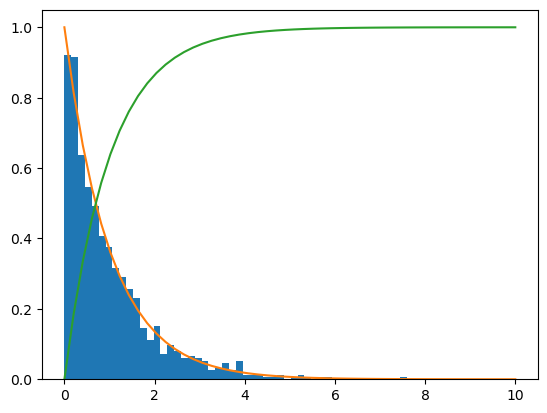

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp 

#1
campione = sp.stats.gamma(a=1)
sample = campione.rvs(size=1000)
#2
plt.hist(sample,bins=50,density=True)
x = np.linspace(0,10)
plt.plot(x,campione.pdf(x))

#3
sp.stats.gamma.fit(sample)

#4
cdf = campione.cdf(x)
plt.plot(x,cdf)

#5
varianza = np.var(sample)








### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

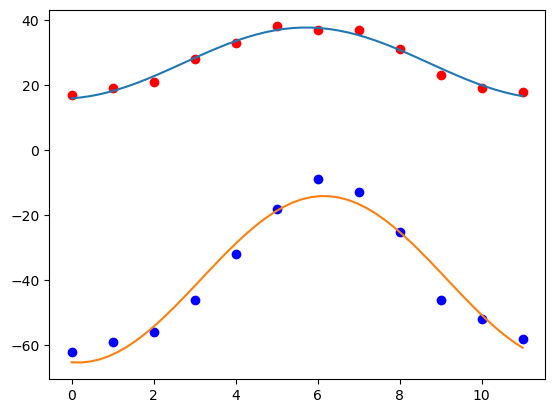

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])

#plotto i dati veri
month = np.arange(12)
plt.plot(month,temp_max,"ro")
plt.plot(month,temp_min,"bo")

def polinomio_grado_3(x,a,b,c,d): # funzione per fare la curva da un polinomio ma non ottimale 
    return a*x**3 + b*x**2 + c*x + d

def sin(x,a,b,c):  #uso funzione seno per fare la curva risulta molto meglio
    return c + a*np.sin((x+b)*2*np.pi/12)

param_max, _ = sp.optimize.curve_fit(sin,month,temp_max)
param_min, _ = sp.optimize.curve_fit(sin,month,temp_min)

x = np.linspace(0,11)
plt.plot(x,sin(x,*param_max)) #plotto le curve fittate
plt.plot(x,sin(x,*param_min))


### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

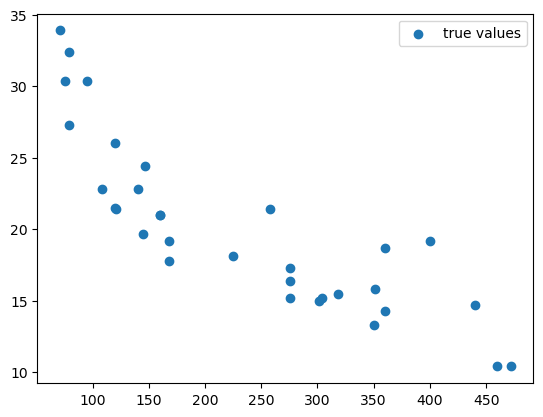

In [3]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df


x = df['disp']
y = df['mpg']
slope , intercept , *_ = sp.stats.linregress(x,y)

y_pred = slope*x + intercept

plt.scatter(x,y,label = 'true values')
plt.legend()
plt.show()
